# Figure 2.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  03/04/2026          |
| Updated |  03/04/2026          |

Maximum dust density $\mathrm{max}(\rho_\mathrm{d})$ as a function of time $t < 10T$ for Problem~BA at grid resolution $512^2$.
The units for density and time are the initially uniform gas density $\rho_\mathrm{g,0}$ and the local orbital period $T$, respectively.
Using a similar cadence for each time series, dotted lines show particle codes (with average of $n_\mathrm{p} = 1$ particle per grid cell/point), solid lines show codes with pressureless dust fluids, and colors differentiate the codes (Sections 2.1.2, 2.1.3, and 2.2, respectively).

In [1]:
#===============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np
import pandas as pd

res = 512
root = f'../{res}/src'
n_p = 'np1'
runs = {
    f'dust_particles/{n_p}': {
        'ls': 'dotted',
        'codes' : {
            'Athena':       'tab:green',
            'Athena++':     'tab:red',
            'Pencil':       'tab:blue',
            'PLUTO':        'tab:pink'
        }
    },
    'dust_fluid': {
        'ls': 'solid',
        'codes' : {
            'Athena++':     'tab:purple',
            'FARGO3D':      'tab:olive',
            'Idefix':       'tab:orange',
            'LA-COMPASS':   'tab:cyan',
            'PLUTO':        'tab:brown'
        }
    }
}

Athena samples
	  Total: 10001
	Strided: 667
	Per 10T: 1000
Athena++ samples
	  Total: 2000
	Strided: 667
	Per 10T: 222
Pencil samples
	  Total: 2925
	Strided: 732
	Per 10T: 292
PLUTO samples
	  Total: 1002
	Strided: 501
	Per 10T: 111
Athena++ samples
	  Total: 100014
	Strided: 633
	Per 10T: 10001
FARGO3D samples
	  Total: 631
	Strided: 631
	Per 10T: 63
Idefix samples
	  Total: 1002
	Strided: 501
	Per 10T: 100
LA-COMPASS samples
	  Total: 31401
	Strided: 641
	Per 10T: 3489
PLUTO samples
	  Total: 1001
	Strided: 501
	Per 10T: 100


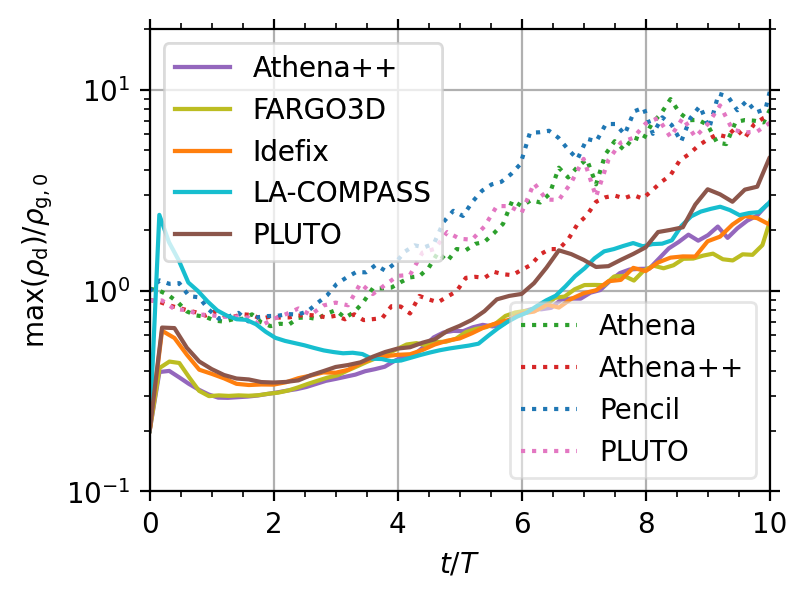

In [2]:
#===============================================================================
def print_samples(code, t, step, dt, window):
    """Print the number of samples in the time series."""
    print(f'{code} samples\n=======================')
    print(f'\t  Total: {len(t)}')
    print(f'\tStrided: {len(t[::step])}')
    print(f'\tPer {dt}T: {window}')

diag = True
dt = 10  # [T]

# Lowest cadence
path = f'{root}/dust_fluid/FARGO3D'
n_min = len(np.load(f'{path}/time_series.npz')['t'])

# Plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=200)
loc = 'lower right'
for key, value in runs.items():
    if key == 'dust_fluid':
        loc = 'upper left'
    handles = []
    for code, color in value['codes'].items():
        path = f'{root}/{key}/{code}'
        data = np.load(f'{path}/time_series.npz')
        t = data['t']
        # Stride
        step = len(t)//n_min
        if step < 2:
            step = 1 if len(t)%n_min/n_min < 0.5 else 2
        try:
            handles.append(ax.plot(t[::step], data['maxrhod'][::step], c=color,
                           label=code, ls=value['ls'])[0])
        except KeyError:
            print(code)
        window = len(t)//int(t[-1]/dt)
        print_samples(code, t, step, dt, window) if diag else None
    ax.add_artist(ax.legend(framealpha=0.5, handles=handles, loc=loc))

# Format plots
ax.grid()
ax.minorticks_on()
ax.set(xlabel=r'$t/T$', xlim=(0, 10), ylim=(1e-1, 2e1), yscale='log',
       ylabel=rf'$\max(\rho_\mathrm{{d}})/\rho_\mathrm{{g,0}}$')
ax.tick_params(axis='both', which='both', top=True, right=True)